# Bella Lui - 3 DOF Simulation with Point Mass Objects

This notebook demonstrates the 3 DOF flight simulation capabilities of RocketPy using a simplified version of the Bella Lui rocket from EPFL Rocket Team. The rocket is modeled using PointMassMotor and PointMassRocket for a 3 DOF trajectory simulation.

**Note**: This is a simplified model for demonstration purposes. For accurate flight predictions, use the full 6 DOF model in `bella_lui_flight_sim.ipynb`.

In [1]:
# Importing libraries
import matplotlib.pyplot as plt
import numpy as np

from rocketpy import Environment, Flight
from rocketpy.motors.point_mass_motor import PointMassMotor
from rocketpy.rocket.point_mass_rocket import PointMassRocket

## Environment Setup

Setting up the environment for the Bella Lui launch at Kaltbrunn, Switzerland.


Gravity Details

Acceleration of gravity at surface level:    9.8100 m/s²
Acceleration of gravity at   1.000 km (ASL): 9.8100 m/s²


Launch Site Details

Launch Date: 2020-02-22 13:00:00 UTC
Launch Site Latitude: 47.21348°
Launch Site Longitude: 9.00334°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 500252.61 E    5228887.37 N
Launch Site UTM zone: 32T
Launch Site Surface Elevation: 407.0 m


Atmospheric Model Details

Atmospheric Model Type: Reanalysis
Reanalysis Maximum Height: 1.000 km
Reanalysis Time Period: from 2020-02-22 00:00:00 to 2020-02-22 18:00:00 utc
Reanalysis Hour Interval: 4 hrs
Reanalysis Latitude Range: From 48.0° to 46.0°
Reanalysis Longitude Range: From 8.0° to 10.0°

Surface Atmospheric Conditions

Surface Wind Speed: 1.26 m/s
Surface Wind Direction: 213.21°
Surface Wind Heading: 33.21°
Surface Pressure: 980.43 hPa
Surface Temperature: 286.63 K
Surface Air Density: 1.192 kg/m³
Surface Speed of Sound: 339.39 m/s


Earth Model Details

Earth Radius at Lau

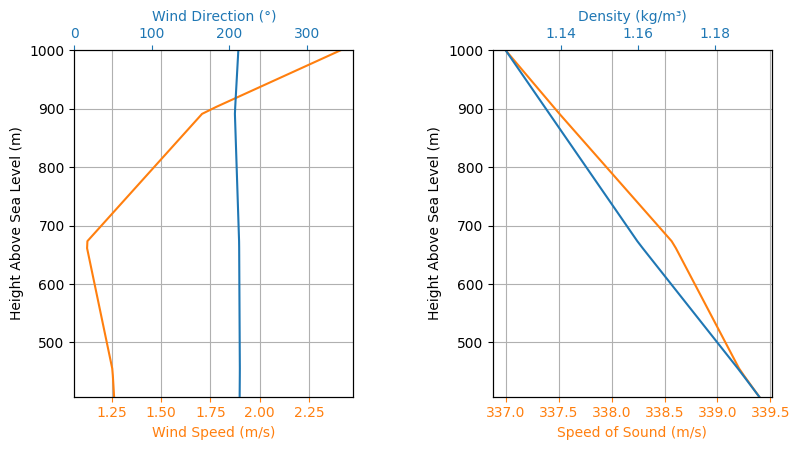

In [2]:
# Environment conditions
env = Environment(
    gravity=9.81,
    latitude=47.213476,
    longitude=9.003336,
    date=(2020, 2, 22, 13),
    elevation=407,
)

env.set_atmospheric_model(
    type="Reanalysis",
    file="../../data/weather/bella_lui_weather_data_ERA5.nc",
    dictionary="ECMWF",
)

env.max_expected_height = 1000

# Display environment info
env.info()

## Motor Configuration

Creating a simplified PointMassMotor based on the AeroTech K828FJ motor characteristics:
- Total impulse: ~2157 N·s
- Burn time: ~2.43 s
- Average thrust: ~888 N
- Propellant mass: ~1.373 kg

Motor Details
Total Burning Time: 2.43 s
Total Propellant Mass: 1.373 kg
Structural Mass Ratio: 0.421
Average Propellant Exhaust Velocity: 1571.624 m/s
Average Thrust: 888.000 N
Maximum Thrust: 888.0 N at 0.0 s after ignition.
Total Impulse: 2157.840 Ns



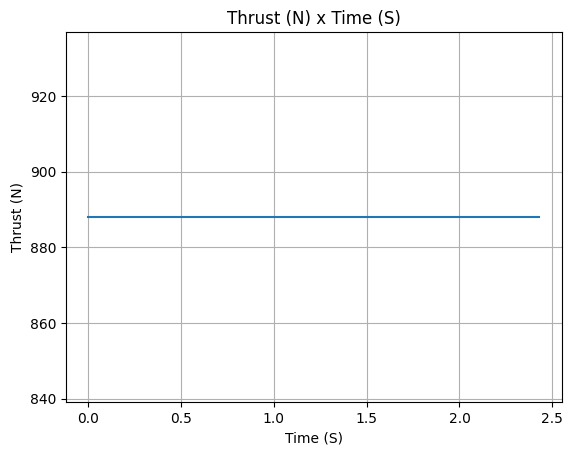

In [3]:
# Simplified motor based on K828FJ characteristics
# Total impulse = 2157 N·s, burn time = 2.43 s, average thrust = 888 N
motor = PointMassMotor(
    thrust_source=888,  # Average thrust in N
    dry_mass=1.0,  # Motor casing mass in kg
    propellant_initial_mass=1.373,  # Propellant mass in kg
    burn_time=2.43,  # Burn time in seconds
)

# Display motor information
motor.info()

## Rocket Configuration

Creating a PointMassRocket with Bella Lui's key characteristics:
- Radius: 0.078 m (156 mm diameter)
- Dry mass (without motor): ~17.227 kg
- Drag coefficients based on Bella Lui data

In [4]:
# Bella Lui rocket parameters
rocket = PointMassRocket(
    radius=0.078,  # 156 mm diameter
    mass=17.227,  # Dry mass without motor (18.227 - 1.0 motor dry mass)
    center_of_mass_without_motor=0.0,  # Simplified CM position
    power_off_drag=0.43,  # Drag coefficient when motor is off
    power_on_drag=0.43,  # Drag coefficient when motor is on
)

# Add motor to the rocket
rocket.add_motor(motor, position=0)

# Display rocket information
rocket.info()


Inertia Details

Rocket Mass: 17.227 kg (without motor)
Rocket Dry Mass: 18.227 kg (with unloaded motor)
Rocket Loaded Mass: 19.600 kg
Rocket Structural Mass Ratio: 0.930
Rocket Inertia (with unloaded motor) 11: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.078 m
Rocket Frontal Area: 0.019113 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 0.000 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.000 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.000 m


Aerodynamics Lift Coefficient Derivatives


Center of Pressure


Stability

Center of Mass position (time=0): 0.000 m
Center of Pressure position (time=0): 0.000

## Flight Simulation (3 DOF)

Running the flight simulation in 3 DOF mode with launch parameters similar to the Bella Lui mission.

In [5]:
# Create 3 DOF flight simulation
flight = Flight(
    rocket=rocket,
    environment=env,
    rail_length=4.2,  # Rail length in meters
    inclination=89,  # Nearly vertical launch (89 degrees from horizontal)
    heading=45,  # Launch heading in degrees
    simulation_mode="3 DOF",  # 3 DOF simulation mode
    max_time=100,  # Maximum simulation time in seconds
)

# Display basic flight information
print(f"Simulation Mode: {flight.simulation_mode}")
print(f"Apogee Altitude: {flight.apogee:.2f} m")
print(f"Apogee Time: {flight.apogee_time:.2f} s")
print(f"Maximum Velocity: {flight.max_speed:.2f} m/s")
print(f"Impact Velocity: {flight.impact_velocity:.2f} m/s")

Simulation Mode: 3 DOF
Apogee Altitude: 877.47 m
Apogee Time: 10.90 s
Maximum Velocity: 102.39 m/s
Impact Velocity: -102.37 m/s


## Flight Plots

The following cells demonstrate that all plotting functions work correctly with 3 DOF simulations, including the `energy_data()` plot that previously failed.

### Trajectory 3D Plot

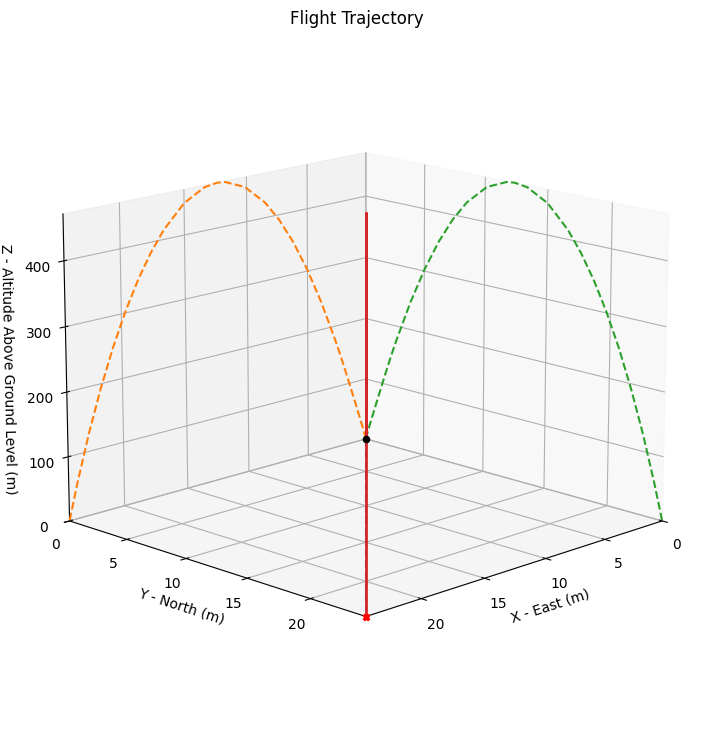

In [6]:
flight.plots.trajectory_3d()

### Linear Kinematics

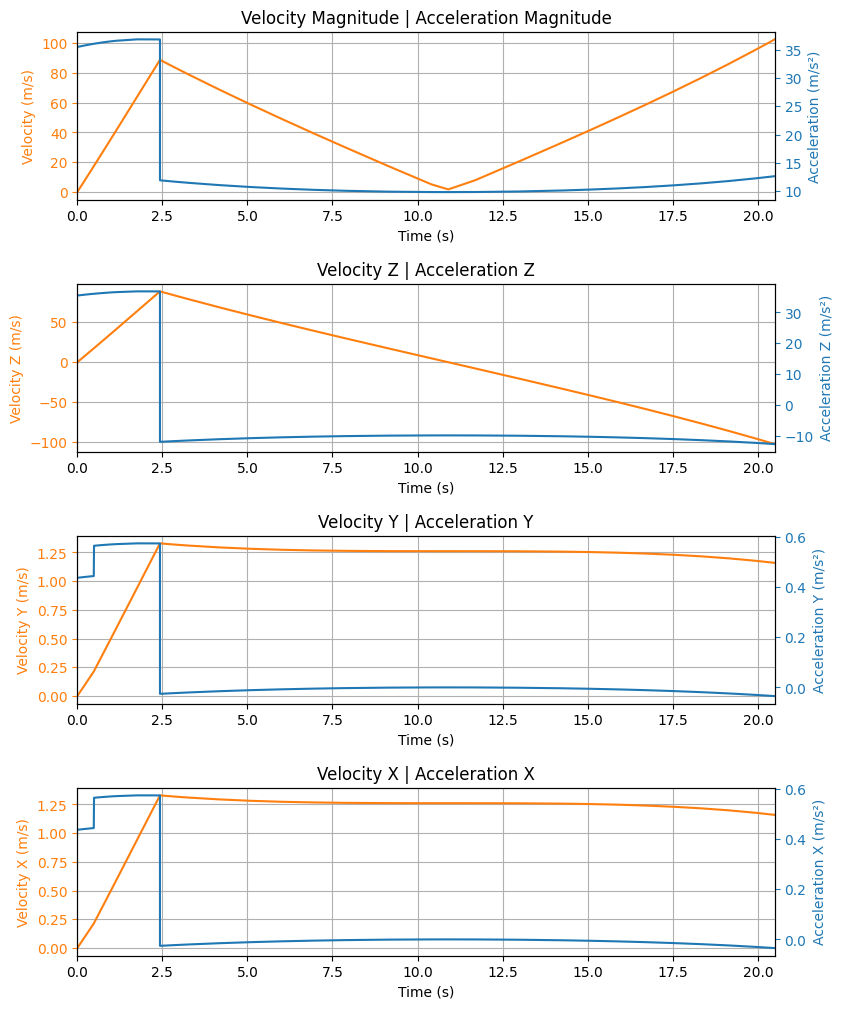

In [7]:
flight.plots.linear_kinematics_data()

### Attitude Data

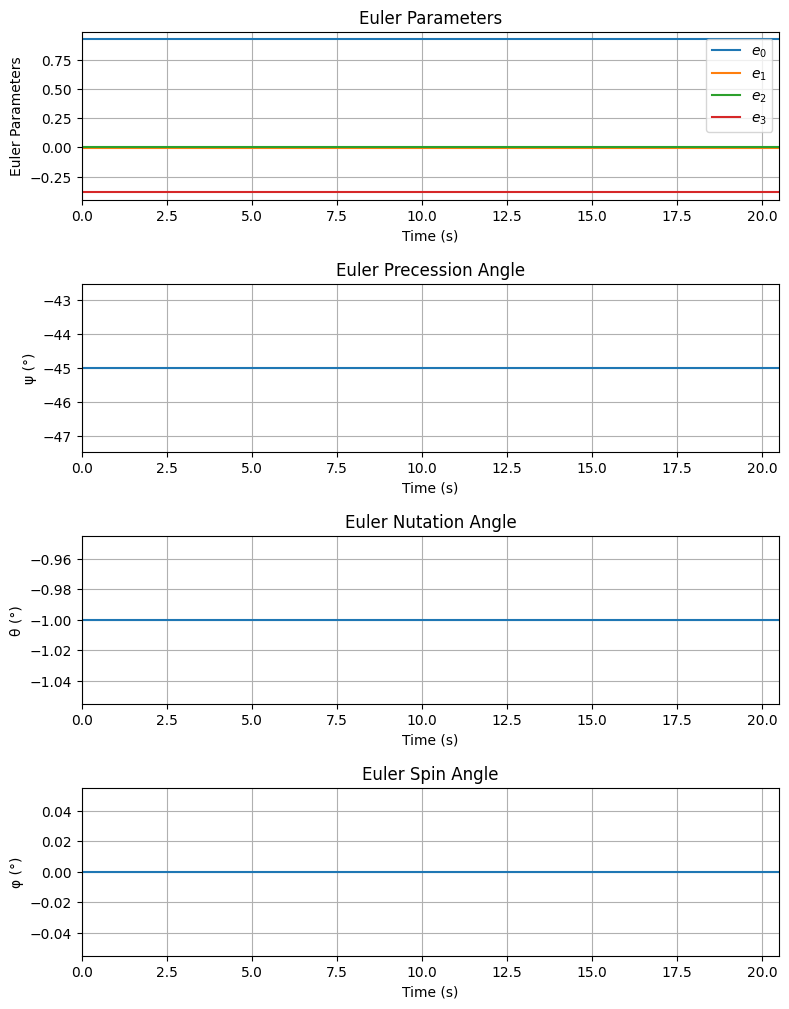

In [8]:
flight.plots.attitude_data()

### Flight Path Angle

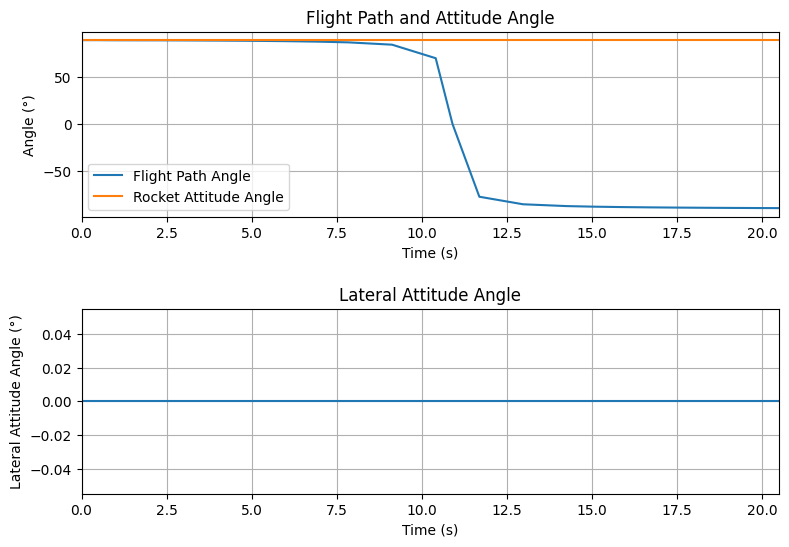

In [9]:
flight.plots.flight_path_angle_data()

### Angular Kinematics

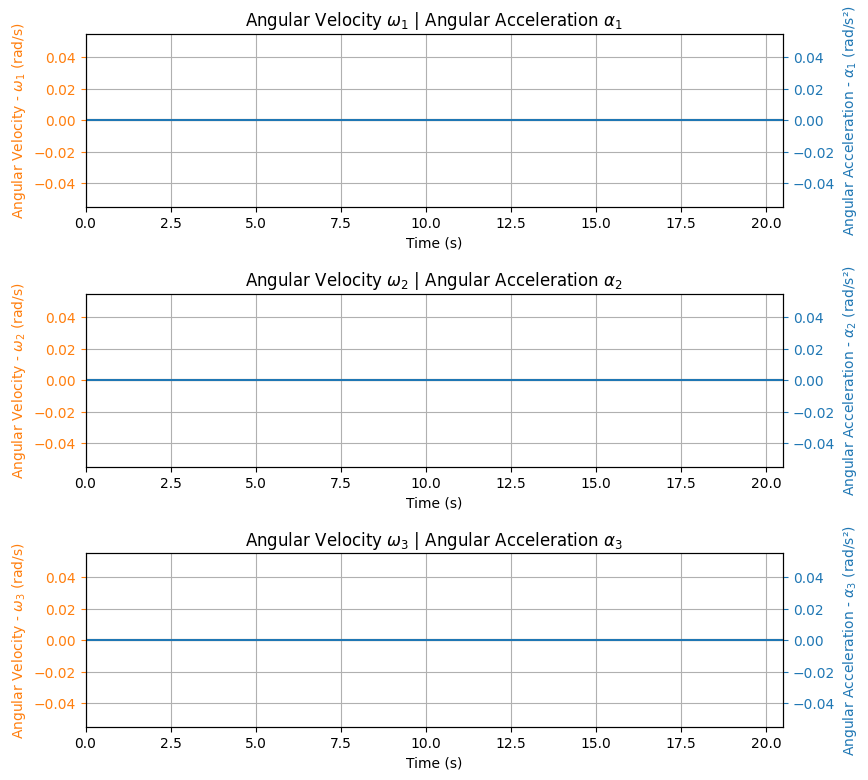

In [10]:
flight.plots.angular_kinematics_data()

### Aerodynamic Forces

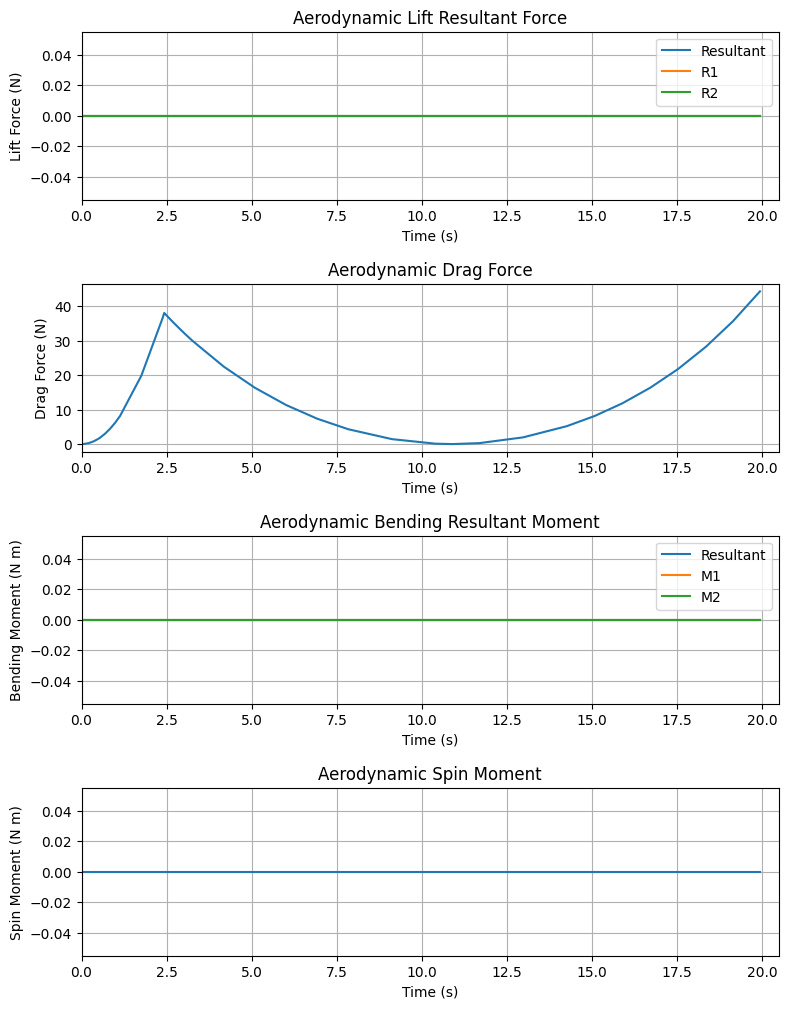

In [11]:
flight.plots.aerodynamic_forces()

### Energy Data

**This plot previously failed for 3 DOF simulations but now works correctly!**

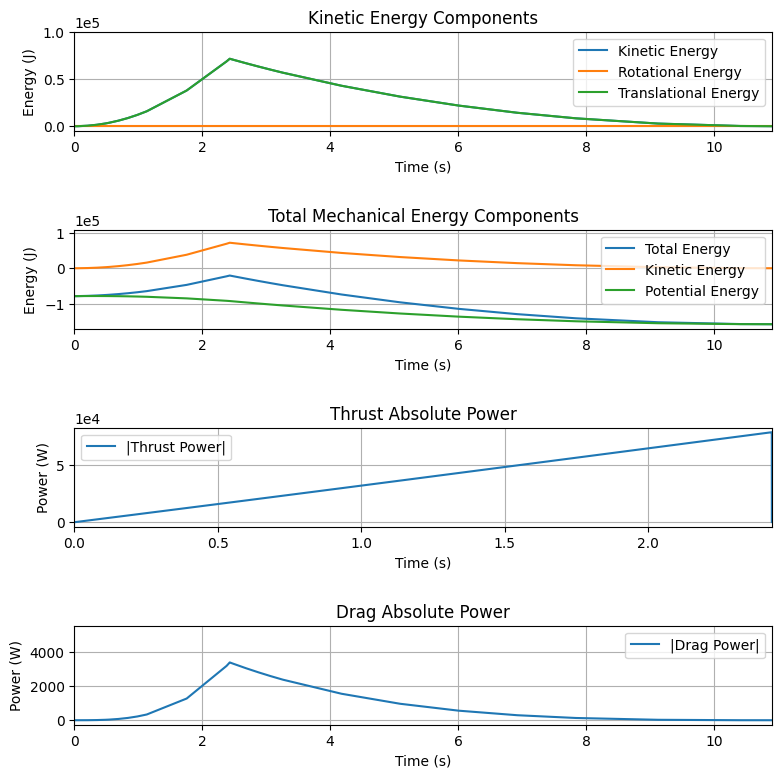

In [12]:
# This plot requires net_thrust, which is now available in 3 DOF mode
flight.plots.energy_data()

### Fluid Mechanics

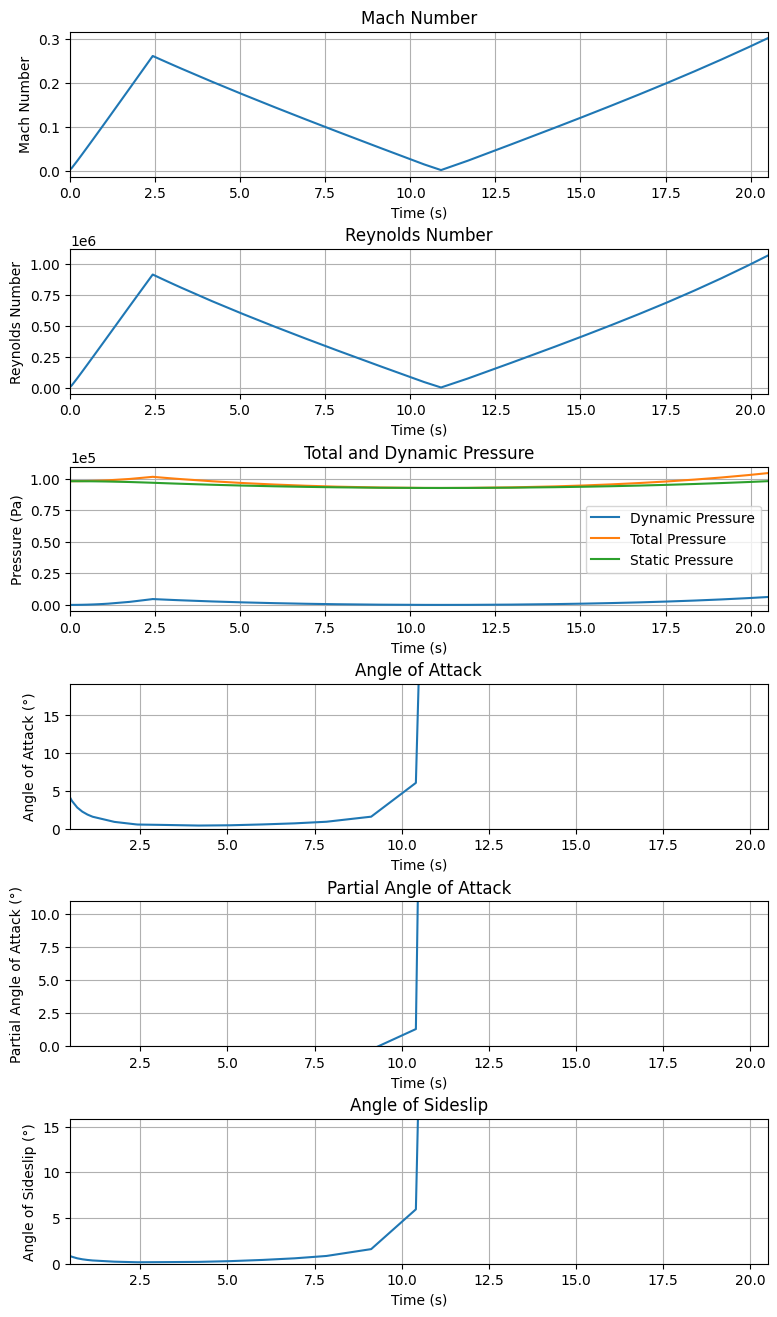

In [13]:
flight.plots.fluid_mechanics_data()

### Stability and Control

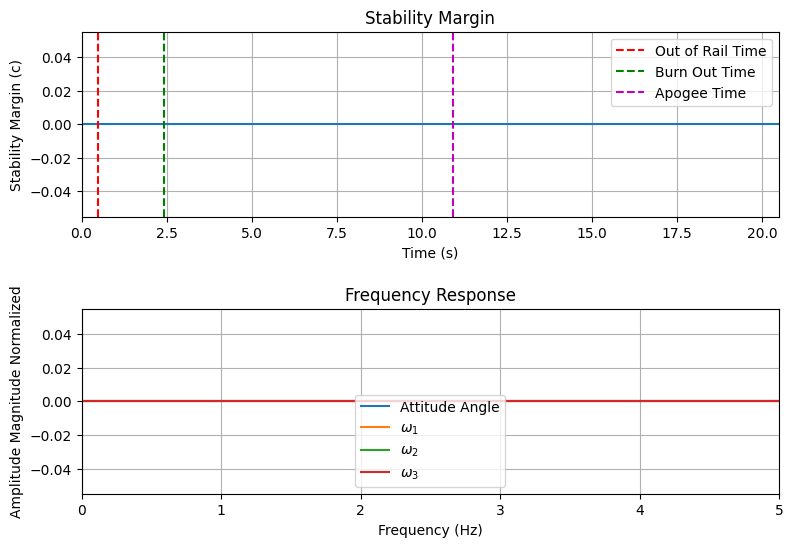

In [14]:
flight.plots.stability_and_control_data()

### Pressure vs Altitude

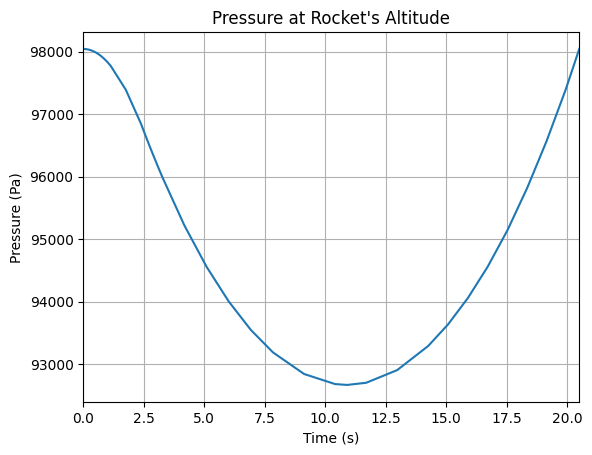

In [15]:
flight.plots.pressure_rocket_altitude()

## All Plots at Once

The `plots.all()` method generates all available plots. This demonstrates that all plotting functionality works correctly for 3 DOF simulations.



Trajectory 3d Plot



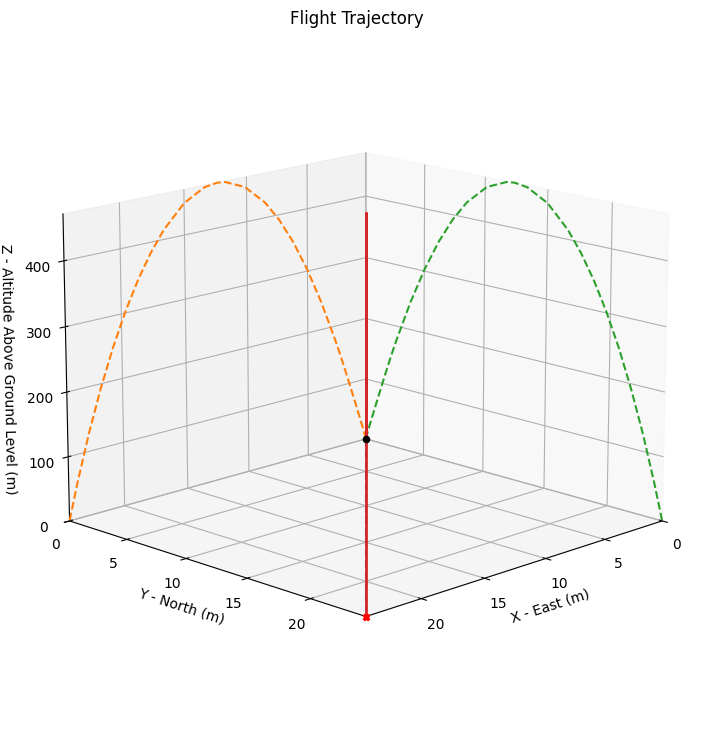



Trajectory Kinematic Plots



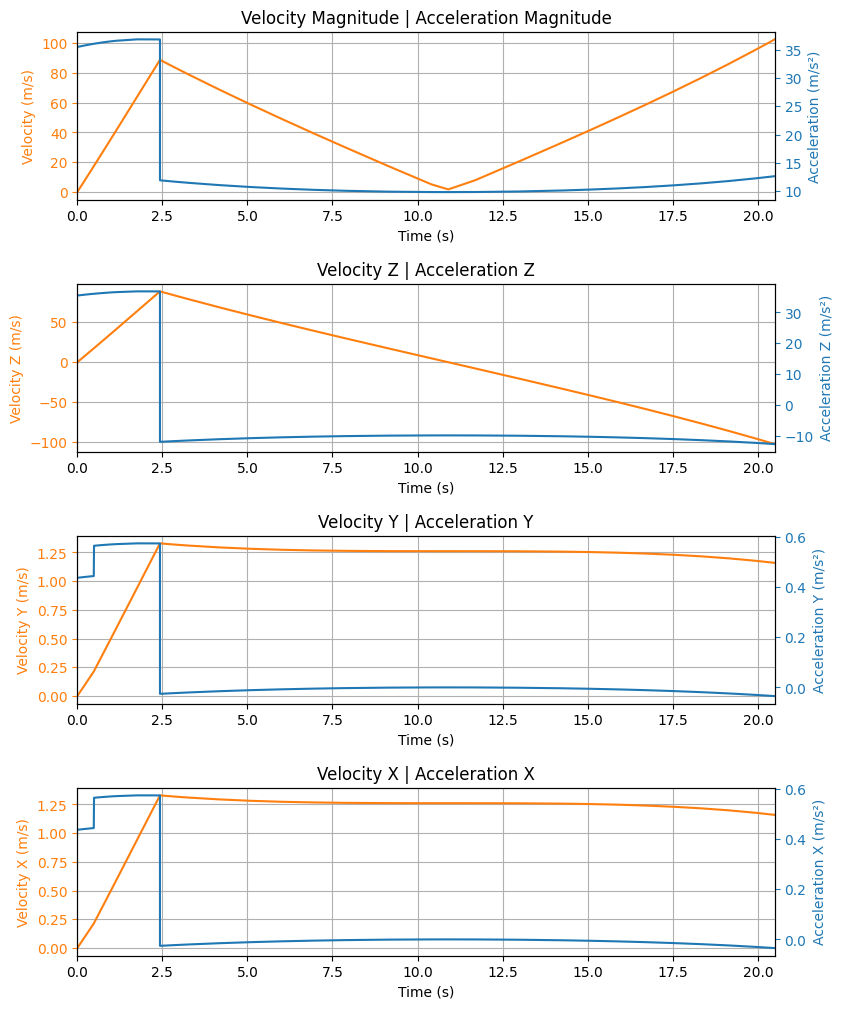



Angular Position Plots



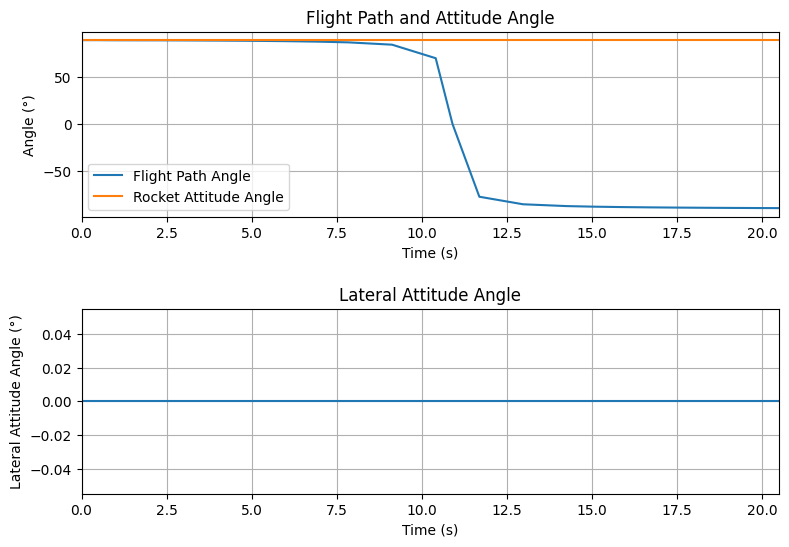



Path, Attitude and Lateral Attitude Angle plots



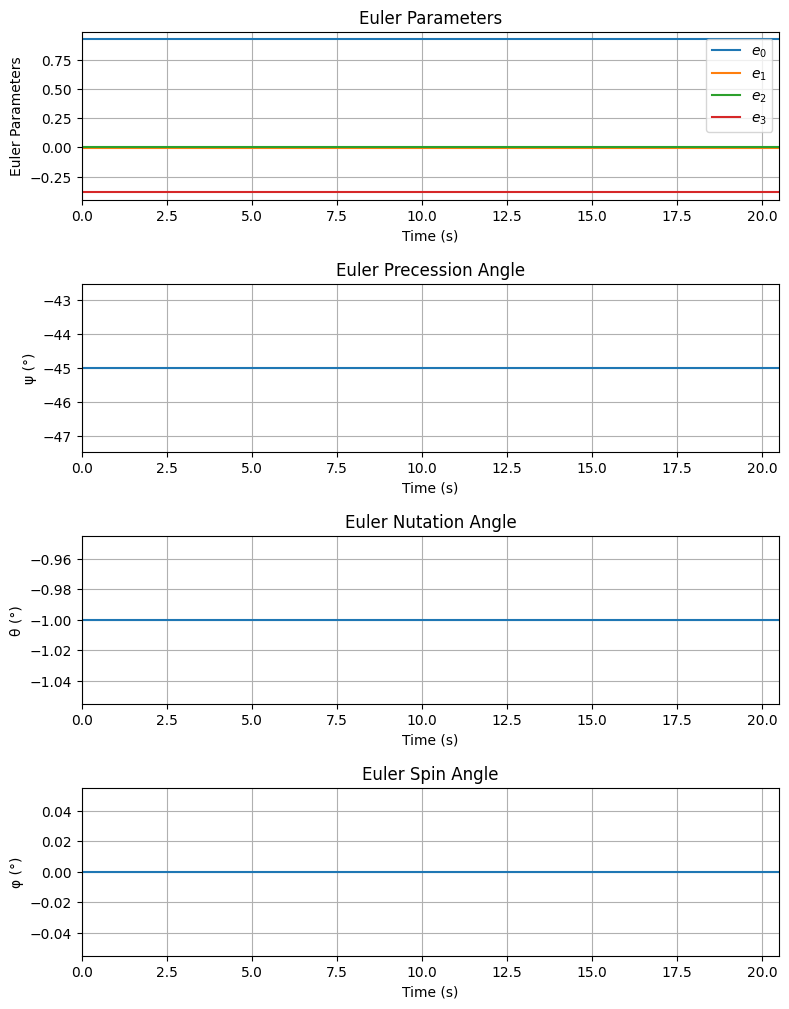



Trajectory Angular Velocity and Acceleration Plots



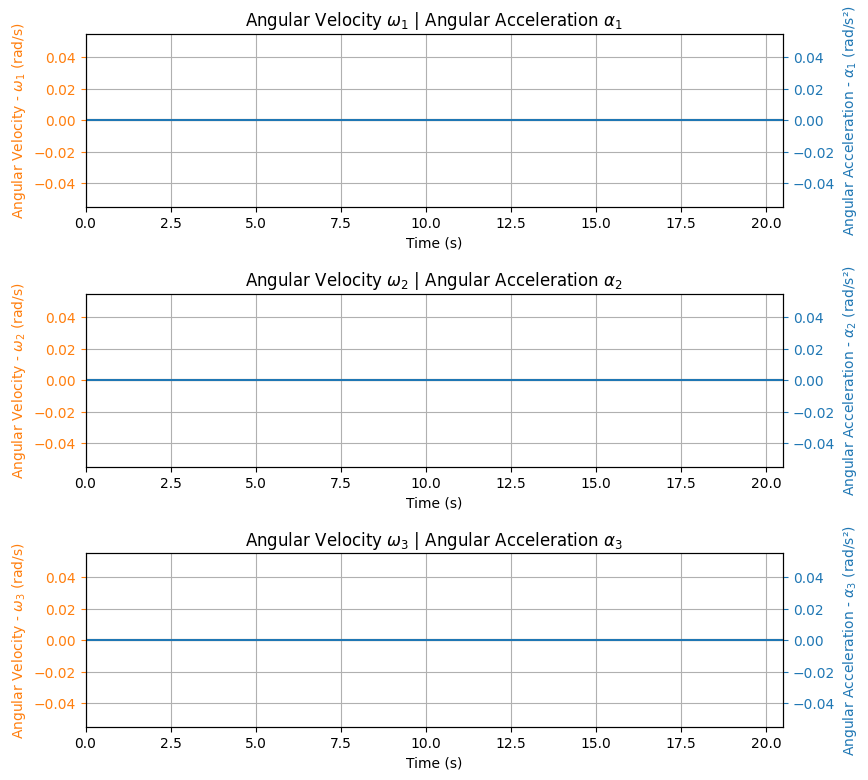



Aerodynamic Forces Plots



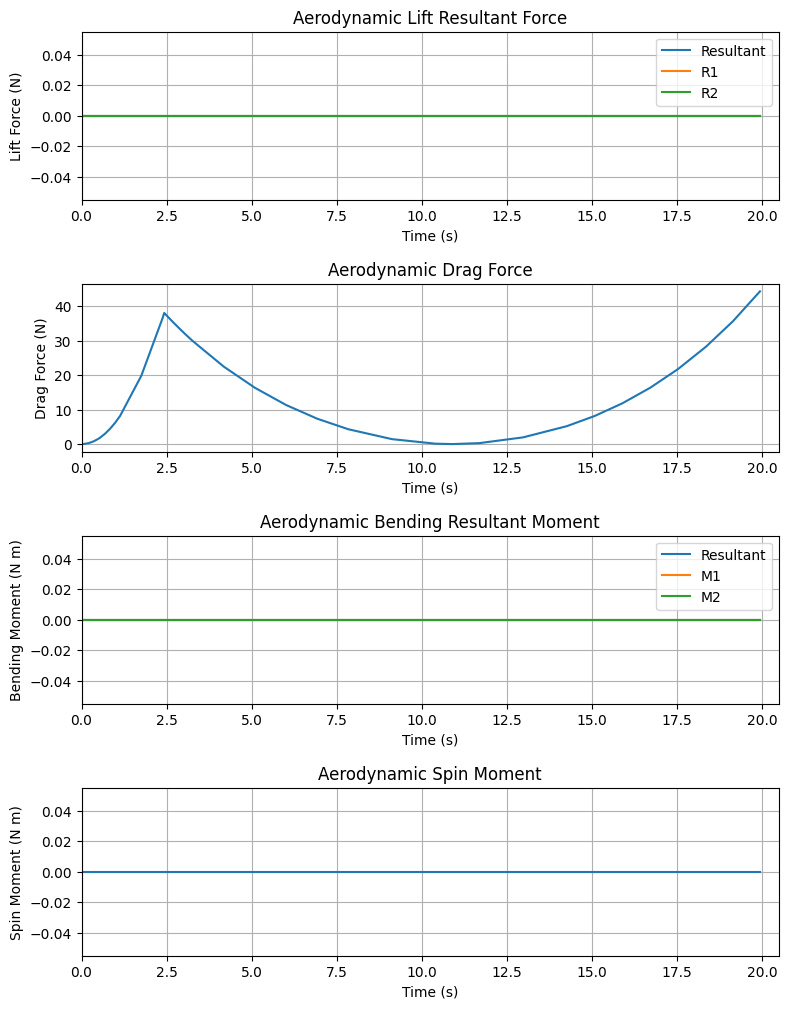



Rail Buttons Bending Moments Plots

No rail buttons were defined. Skipping rail button bending moment plots.


Rail Buttons Forces Plots

No rail buttons were defined. Skipping rail button plots.


Trajectory Energy Plots



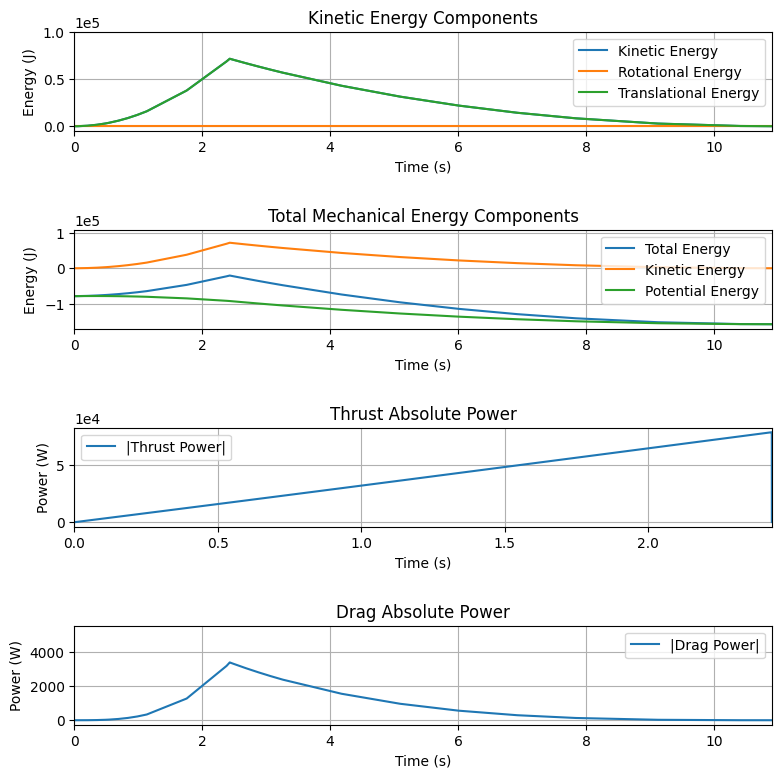



Trajectory Fluid Mechanics Plots



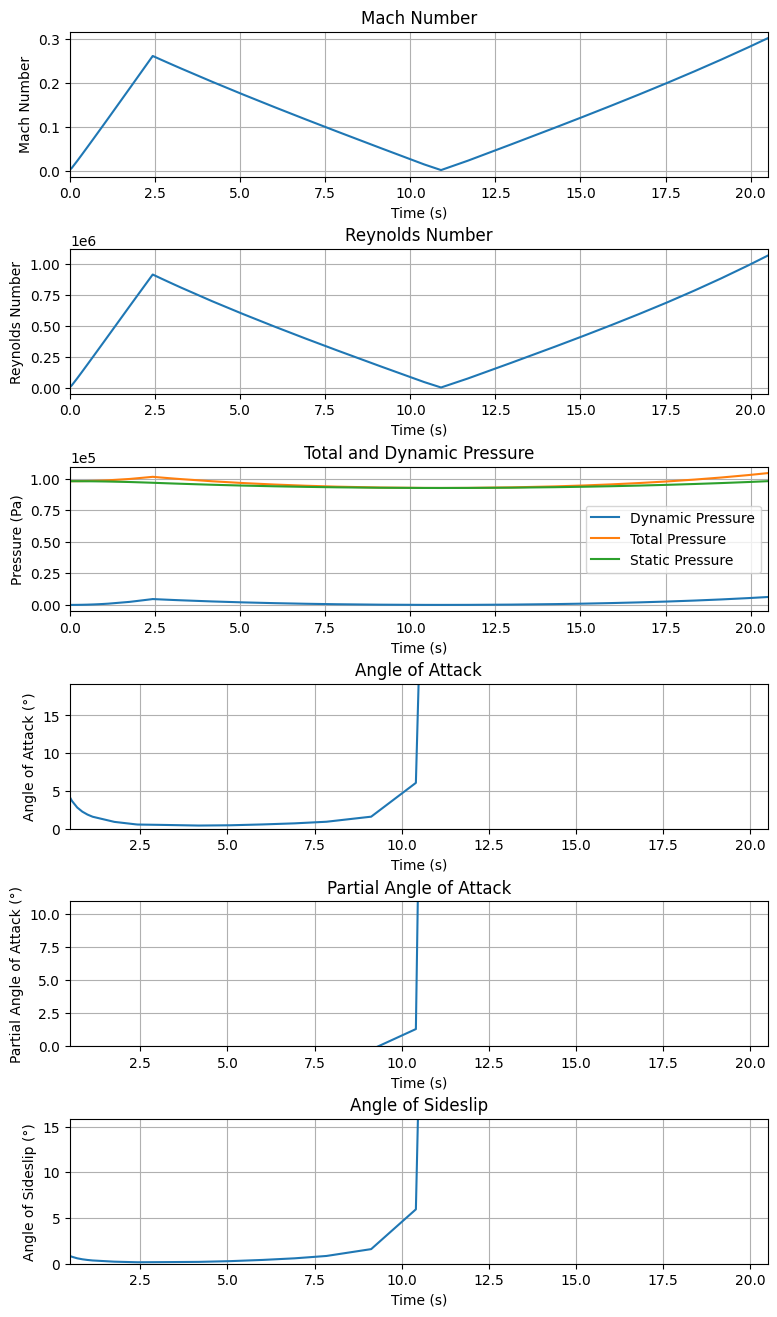



Trajectory Stability and Control Plots



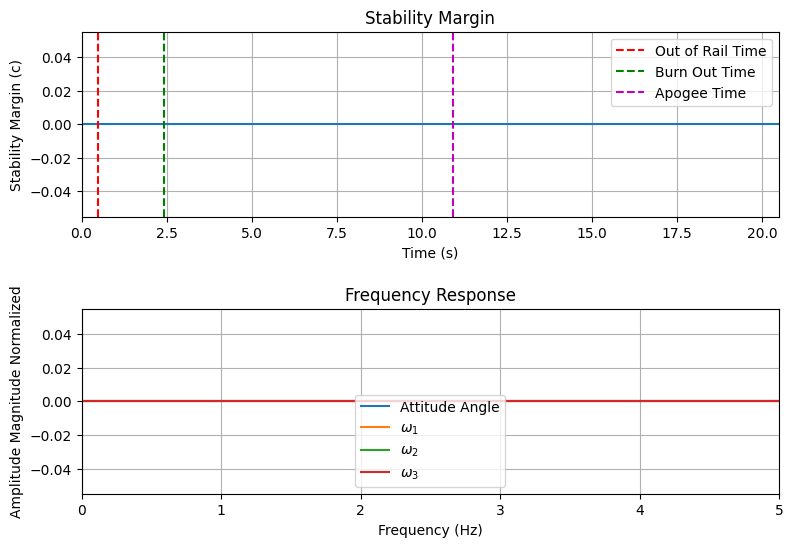



Rocket and Parachute Pressure Plots



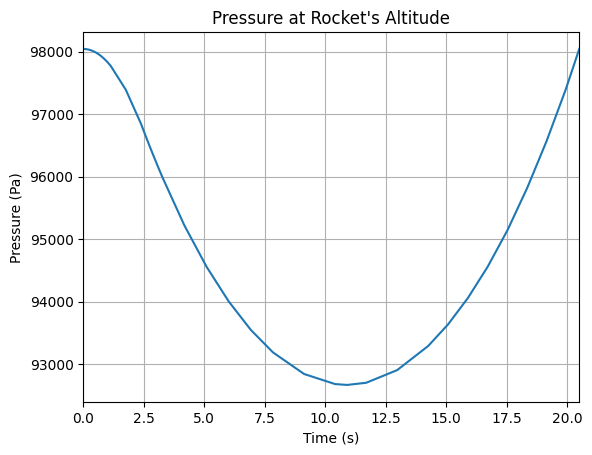


Rocket has no parachutes. No parachute plots available


In [16]:
# Generate all plots
flight.plots.all()

## Summary

This notebook demonstrates:

1. **3 DOF Simulation**: Using PointMassMotor and PointMassRocket for simplified trajectory analysis
2. **Complete Plotting Support**: All plot methods work correctly in 3 DOF mode, including:
   - Trajectory plots
   - Kinematics (linear and angular)
   - Energy data (previously failed, now fixed!)
   - Aerodynamic forces
   - Fluid mechanics
   - Stability and control
3. **Bella Lui Model**: Simplified version based on real flight data from EPFL Rocket Team

### Key Differences from 6 DOF:

- **3 DOF**: Simplified point mass model, faster computation, suitable for preliminary analysis
- **6 DOF**: Full rigid body dynamics with rotation, more accurate, required for detailed flight analysis

### When to Use 3 DOF:

- Quick trajectory estimates
- Preliminary design studies
- Monte Carlo simulations with many runs
- When rotational dynamics are not critical

For the complete 6 DOF simulation of Bella Lui with full aerodynamic surfaces and detailed motor modeling, see `bella_lui_flight_sim.ipynb`.